# Computer Vision
## Exercise Sheet 4: Greedy snake
### Erhardt Barth / Christoph Linse / Manuel Laufer / Kathleen Anderson
Universität zu Lübeck, Institut für Neuro- und Bioinformatik

In case of questions, contact us via email: *{erhardt.barth, c.linse, m.laufer, k.anderson} @uni-luebeck.de*

## Note: Please insert the names of all participating students:

1. 
2. 
3. 
4. 
5. 


In [1]:
import sys, os
if 'google.colab' in sys.modules:
  if os.getcwd() == '/content':
    !git clone 'https://github.com/inb-luebeck/cs4250.git'
    os.chdir('cs4250')

In [2]:
import numpy as np
from numpy.linalg import norm
import cv2
import matplotlib.pyplot as plt
%matplotlib inline  

In this exercise, a program framework is given. Add the missing parts for the implementation of a greedy 
snake at the marked sections in the code.

* Use the gradient magnitude as image term.
* Calculate the three energy terms $E_{cont}$, $E_{curv}$, and $E_{imag}$.
* Normalize the energy terms over the neighborhood to the intervall $[0,1]$.
* Estimate the point in the neighborhood, that has minimum energy.


**Hint:** Use the following equations for the implementation of the energy terms:\\
\begin{eqnarray}
E_{cont} & = & (0.5\cdot(\|p_i-p_{i-1}\|-\|p_i-p_{i+1}\|))^2 \\
E_{curv} & = & \|p_{i-1}-2 p_i+p_{i+1}\|^2 \\
E_{imag} & = & -\|\nabla I(x,y)\|
\end{eqnarray}

Comment on the difference between using $E_{cont}$ described above and the term $(\bar d-\|p_i-p_{i-1}\|)^2$ given in the lecture.

| Property                    | Exercise                                                      | Lecture                                                   |
| --------------------------- | ------------------------------------------------------------- | --------------------------------------------------------- |
| Reference                   | Local: difference between the two neighbouring distances      | Global: deviation from the mean contour spacing $\bar{d}$ |
| Enforces                    | Equal spacing between $p_{i−1}$​ and $p_{i+1}$​ around $p_i$​ | Each arc-length step equals the global average            |
| Fixed global scale          | No- only cares about local symmetry                           | Yes- penalizes deviation from $\bar{d}$                   |
| Behaviour on large contours | Can allow drift of global density while keeping local balance | Resists global bunching or spreading                      |
| Corner sensitivity          | Lower — symmetric positions can still cluster                 | Higher — strong penalty if a region becomes dense         |


In [3]:
def snake(img, contour, **kwargs):
    k     = contour.shape[1]
    alpha = kwargs['alpha'] * np.ones(k)
    beta  = kwargs['beta']  * np.ones(k)
    gamma = kwargs['gamma'] * np.ones(k)

    #TODO: compute gradient image
    grad_x, grad_y         = gradient(img)
    gradient_magnitude     = np.sqrt(grad_x ** 2 + grad_y ** 2) # like last week

    # normalise to [0, 1]  (so E_imag stays in a comparable range)
    gm_min, gm_max         = gradient_magnitude.min(), gradient_magnitude.max()
    norm_image_gradient    = (gradient_magnitude - gm_min) / (gm_max - gm_min + 1e-12)

    k_updated  = k
    iterations = 0

    # iterate until snake stops changing
    while k_updated > k * kwargs['contour_fraction']:
        iterations += 1
        k_updated   = 0

        # update all contour points
        for i in range(k):
            p, updated = greedy_minimization(
                norm_image_gradient, contour, i,
                alpha, beta, gamma, kwargs['neighborhood_size'])

            if p is not None:
                contour[:, i] = p

            # eliminate corners if required
            if iterations > kwargs['begin_corner_elim']:
                beta = corner_elimination(contour, beta, kwargs['K_threshold'])

            # keep track of number of updated points
            if updated:
                k_updated += 1

        # display current state of snake
        print('num_updates: {}'.format(k_updated))
        plt.imshow(norm_image_gradient, cmap='gray')
        plt.plot(contour[1, :], contour[0, :], 'r.-')
        plt.title(f'Iteration {iterations}')
        plt.show()

In [4]:
def greedy_minimization(norm_image_gradient, contour, i, alpha, beta, gamma, neighborhood_size):
    m, n = norm_image_gradient.shape
    k    = contour.shape[1]
    w    = (neighborhood_size - 1.) / 2.
    d    = average_distance(contour)
    updated = False

    # get previous, current, and next point in snake
    p_iminus1 = contour[:, wrap_index(i - 1, k)]
    p_i       = contour[:, i]
    p_iplus1  = contour[:, wrap_index(i + 1, k)]

    # compute individual terms of energy functional
    p = []
    E_cont = []
    E_curv = []
    E_imag = []

    # For all points in a local neighborhood, compute the energy terms
    for p_i_x in np.arange(max(0, p_i[0] - w), min(m - 1, p_i[0] + w) + 1):
        for p_i_y in np.arange(max(0, p_i[1] - w), min(n - 1, p_i[1] + w) + 1):
            # TODO: get the respective vector
            p_candidate = np.array([p_i_x, p_i_y])

            d_prev = norm(p_candidate - p_iminus1)
            d_next = norm(p_candidate - p_iplus1)

            # TODO: compute energy terms
            e_cont = (0.5 * (d_prev - d_next)) ** 2
            e_curv = norm(p_iminus1 - 2. * p_candidate + p_iplus1) ** 2
            e_imag = -norm_image_gradient[int(p_i_x), int(p_i_y)]

            p.append(p_candidate)
            E_cont.append(e_cont)
            E_curv.append(e_curv)
            E_imag.append(e_imag)

    if not p:
        return None, False          # ← explicit tuple, not bare None

    # TODO: normalize individual terms of energy functional
    def normalize(arr):
        arr = np.array(arr, dtype=float)
        mn, mx = arr.min(), arr.max()
        if mx - mn < 1e-12:
            return np.zeros_like(arr)
        return (arr - mn) / (mx - mn)

    E_total  = (alpha[i] * normalize(E_cont)
              + beta[i]  * normalize(E_curv)
              + gamma[i] * normalize(E_imag))

    best_idx = int(np.argmin(E_total))
    # compute energy functional and determine minimum
    new_p_i  = p[best_idx]

    # determine if the current point of snake was moved
    if (p_i - new_p_i).sum() != 0:
        updated = True

    return new_p_i, updated

In [5]:
def gradient(image):
    v = .5
    k_y = np.zeros((3, 3))
    k_y[0, 1] = -v
    k_y[2, 1] = +v

    k_x = np.zeros((3, 3))
    k_x[1, 0] = -v
    k_x[1, 2] = +v

    image = np.copy(image).astype('float32')

    gradient_x = cv2.filter2D(image, -1, k_x)
    gradient_y = cv2.filter2D(image, -1, k_y)

    return gradient_x, gradient_y

In [6]:
def load_image_gray_normalized(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.astype('float32')/255.

In [7]:
def wrap_index(index, k):
    if index < 0:
        index = k - 1
    elif index > k-1:
        index = 0
    return index

In [8]:
def average_distance(contour):
    avg_dist = 0
    n = contour.shape[1]

    for i in range(n-1):
        avg_dist = avg_dist+norm(contour[:, i] - contour[:, i+1])

    avg_dist = avg_dist+norm(contour[:, -1] - contour[:, 0])
    avg_dist = avg_dist / n

    return avg_dist

In [9]:
def corner_elimination(contour, beta, K_threshold):
    n = contour.shape[1]
    K = []
    # compute curvature of snake at each point
    for i in range(n):
        # get previous, current, and next point in snake
        p_iminus1 = contour[:, wrap_index(i-1, n)]
        p_i = contour[:, i]
        p_iplus1 = contour[:, wrap_index(i+1, n)]
        K.append(((p_iminus1 - 2.*p_i + p_iplus1)**2.).sum())

    # determine local maxima and set beta to zero there
    for i in range(n):
        prev_is_lower = K[wrap_index(i-1, n)] < K[i]
        next_is_lower = K[i] > K[wrap_index(i+1, n)]
        thres_exceeded = K[i] > K_threshold
        if prev_is_lower and next_is_lower and thres_exceeded:
            beta[i] = 0
    
    return beta

Test your implementation of the greedy snake on the provided test images. The files `ueb421.npy` and
`ueb422.npy` contain simple artificial test images. The file `ueb423.npy` contains a natural image. 
Besides the test images `img`, the files contain a initialization for the snake `contour`.

You need to fit the parameter dict `kwargs` to achive good results on the different images.
**What are the relevant parameters, and what is their influence on the resulting segmentation?**

**Debug Tips**: For debugging, it makes sense to test each functionality separately. For example, set alpha and beta to zero and gamma to one. The contour-points should converge to image edges. If this is not the case, something is wrong.

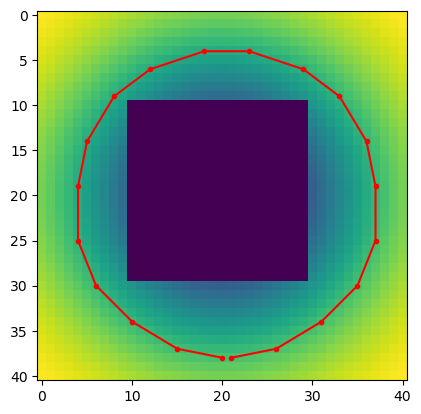

num_updates: 19


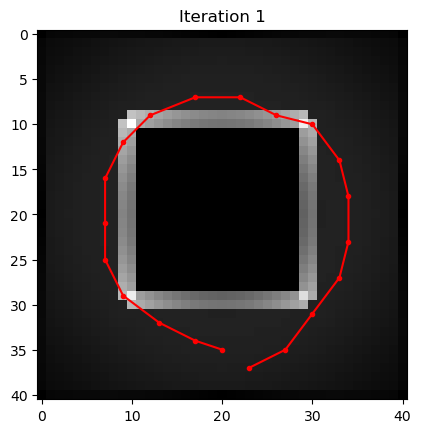

num_updates: 19


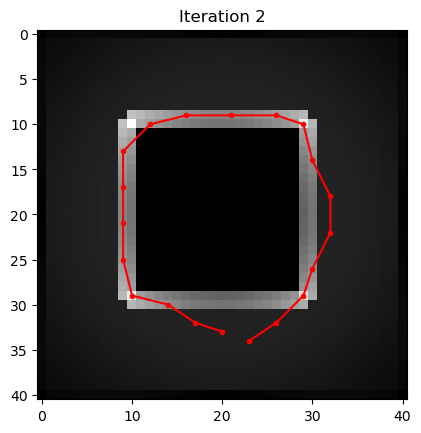

num_updates: 9


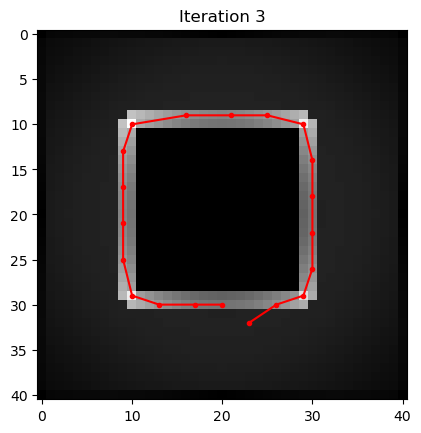

num_updates: 4


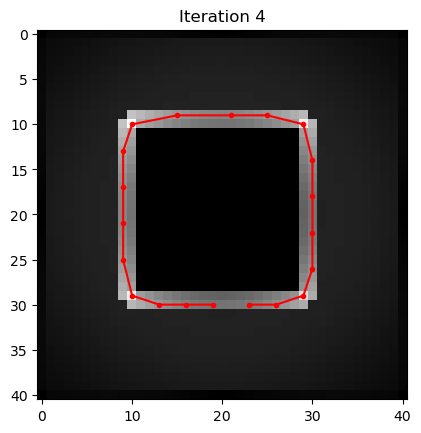

num_updates: 1


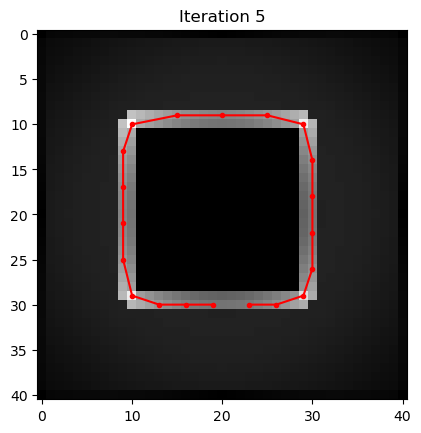

In [10]:
# load image
input_dict = np.load('data/exercise_4/ueb422.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

# set keyword arguments
kwargs = {
    'neighborhood_size': 7,
    'contour_fraction': 0.1,
    'alpha': 1.,
    'beta': 1.,
    'gamma': 1.,
    'begin_corner_elim': 10,
    'K_threshold': 1
}

# run snake
snake(image, contour, **kwargs)

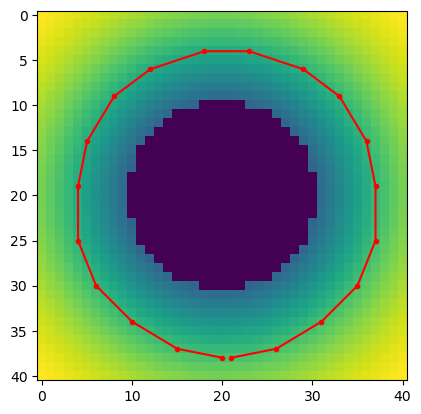

num_updates: 20


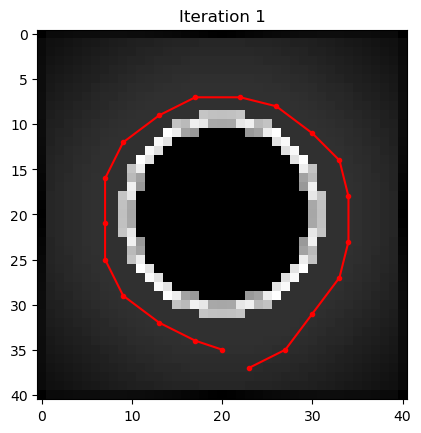

num_updates: 19


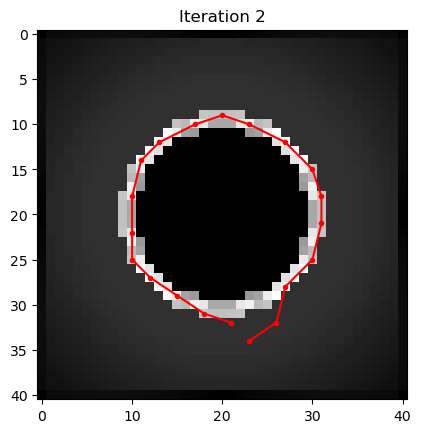

num_updates: 9


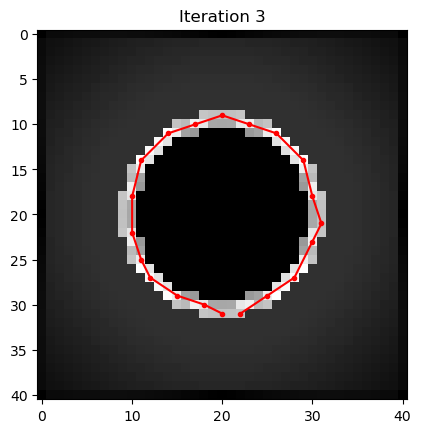

num_updates: 3


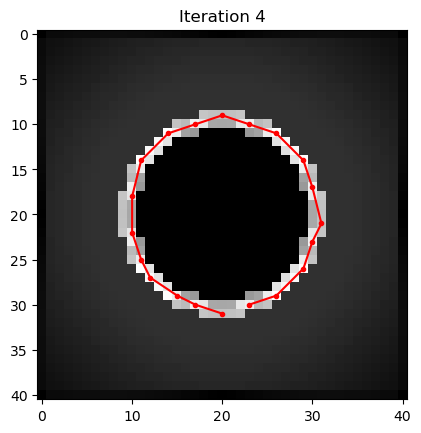

num_updates: 2


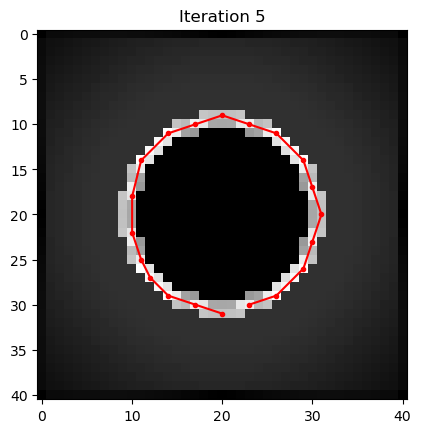

In [11]:
# load image
input_dict = np.load('data/exercise_4/ueb421.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

# set keyword arguments
kwargs = {
    'neighborhood_size': 7,
    'contour_fraction': 0.1,
    'alpha': 1.,
    'beta': 1.,
    'gamma': 1.,
    'begin_corner_elim': 10,
    'K_threshold': 1
}

# run snake
snake(image, contour, **kwargs)

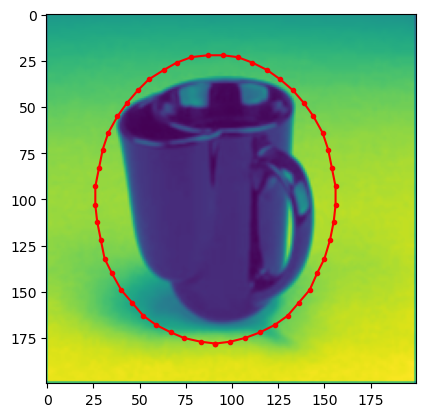

num_updates: 44


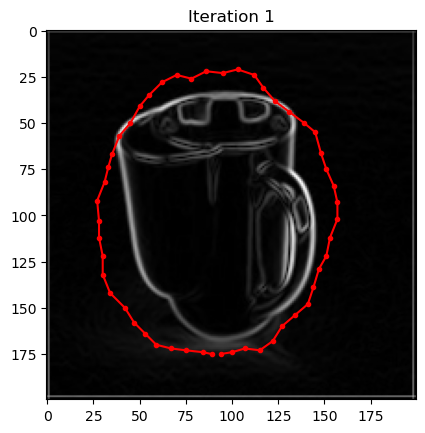

num_updates: 23


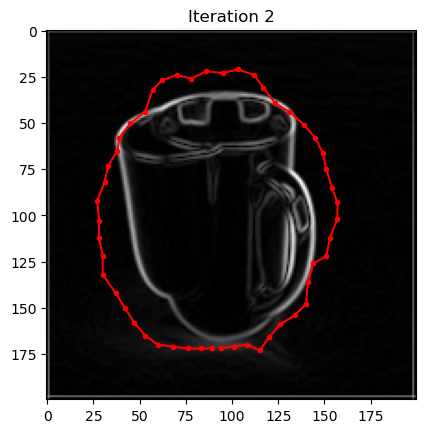

num_updates: 17


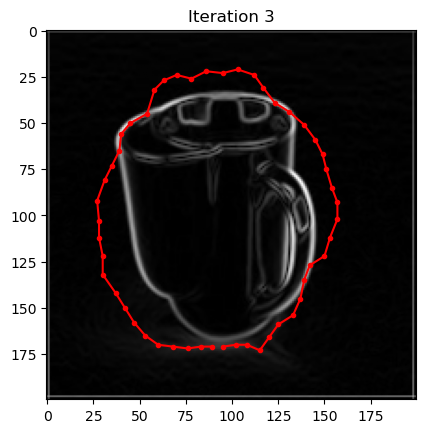

num_updates: 7


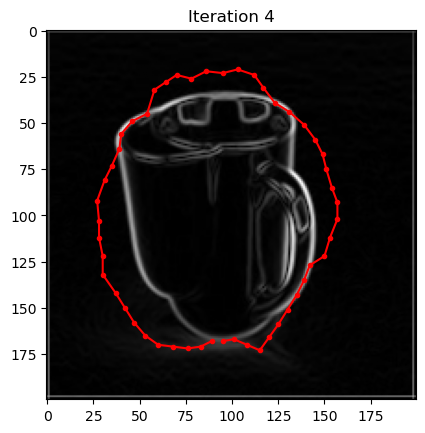

num_updates: 6


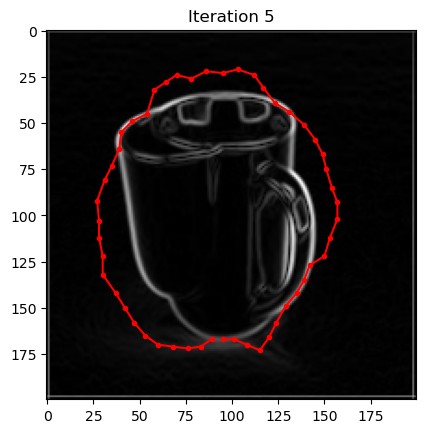

num_updates: 2


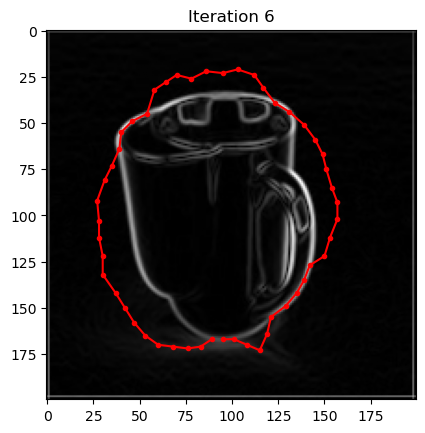

In [12]:
# load image
input_dict = np.load('data/exercise_4/ueb423.npy', allow_pickle=True).item()
image = input_dict['img']
contour = input_dict['contour']

# show initial image & contour
plt.imshow(image)
plt.plot(contour[1, :], contour[0, :], 'r.-')
plt.show()

# set keyword arguments
kwargs = {
    'neighborhood_size': 7,
    'contour_fraction': 0.1,
    'alpha': 1.,
    'beta': 1.,
    'gamma': 1.,
    'begin_corner_elim': 10,
    'K_threshold': 1
}
# run snake
snake(image, contour, **kwargs)